Prédiction de la probabilité de "stress hydrique", le stress hydrique étant considéré ici comme se référant à l'appartenance à la classe "iC-APEX < 0.5", et de l'incertitude associée.

Covariables attendues :
- Raster d'altitude
- Raster de réserve utile (catégoriel)
- Raster de CWB semaine par semaine (le modèle chosira en fonction de la semaine ciblée)
- Données SAFRAN en csv

Variable cible :
- Valeur continue 0 < p < 1 : probabilité de présence pour chaque classe (iC-apex < 0.5 et iC-apex > 0.5)

Le modèle utilise la loss DeepMaxent, AUC-ROC et Accuracy sont calculées comme métriques d'évaluation. Le split est fait par blocs spatiaux et utilise la méthode Leave-One-Block-Out. L'incertitude associée est prédite parallèlement avec la méthode MC-Dropout. Optuna calcule les meilleurs hyperparamètres avant entraînement.

# 0. IMPORTS

In [85]:
# Ignorer les avertissements
import warnings
warnings.filterwarnings('ignore')

# Libraries de base
import numpy as np
import pandas as pd
import os
import ast
import glob
from tqdm import tqdm
from datetime import datetime, timedelta

# Libraries géospatiales
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from shapely.geometry import Point

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.neighbors import BallTree
from sklearn.model_selection import KFold
import torch.optim as optim
import copy

# Working directory
import sys
sys.path.append("C:/Users/juillact/Documents/deep-ApexVigne")

# Modules deep learning personnalisés
from src.model import (
    mlp_model,
    predict_with_uncertainty
)
from src.losses import deepmaxent_loss

# Imports additionnels pour l'entraînement et l'évaluation du modèle
import torch.optim as optim
from scipy.stats import kendalltau
import copy

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Configuration de l'environnement pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. CHARGEMENT DES DONNEES APEX-VIGNE

## 1.1 Charger le jeu de données Apex-vigne

In [86]:
df = pd.read_csv('data/data_irrig_cep.csv', encoding='latin1', low_memory=False)
print(f"{df.shape[0]:,} observations × {df.shape[1]} columns")


46,403 observations × 22 columns


## 1.2 Choix du type de modèle

In [87]:
MODEL_TAG = "classique"

## 1.3 Choix de la date

In [88]:
date_debut_str = "2025-08-11"

## 1.4 Filtre par date

In [89]:
date_debut = pd.to_datetime(date_debut_str)
date_fin = date_debut + pd.Timedelta(days=6)
date_fin_str = date_fin.strftime("%Y-%m-%d")

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut_str) & (df['date_session'] <= date_fin_str)]

print(f"{date_debut_str} → {date_fin_str}")
print(f"Observations sélectionnées : {len(df_filtered):,}/{len(df):,} ({len(df_filtered)/len(df)*100:.2f}%)")

2025-08-11 → 2025-08-17
Observations sélectionnées : 192/46,403 (0.41%)


## 1.5 Conversion en objet spatial

In [90]:
# Conversion en objet spatial
df_filtered_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

## 1.6 Filtrage spatial

In [91]:
# Charger la zone d'étude
study_zone = gpd.read_file("data/study_zone_viti.gpkg")
study_zone_wgs = study_zone.to_crs("EPSG:4326")

# Projection des observations dans le même système de coordonnées que la zone d'étude
df_filtered_sf_proj = df_filtered_sf.to_crs(study_zone.crs)

# Jointure pour filtrer les observations dans la zone d'étude
df_zone = gpd.sjoin(df_filtered_sf_proj, study_zone, how="inner", predicate="within").copy()

print(f"{len(df_zone):,}/{len(df_filtered_sf_proj):,} observations sélectionnées")

# Chargement des départements de la zone d'étude pour l'arrière-plan de la carte
study_zone_bg = gpd.read_file("data/study_zone.gpkg")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")

95/189 observations sélectionnées


## 1.7 Ajouts supplémentaires

### 1.7.1 Identifiant de maille SAFRAN

In [92]:
# Conversion des coordonnées SAFRAN en GeoDataFrame
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs(study_zone.crs)

# Pour chaque observation, on cherche la maille SAFRAN la plus proche et on ajoute l'identifiant 'cell' correspondant
def find_nearest_cell(geom, safran_gdf):
    distances = safran_gdf.geometry.distance(geom)
    return safran_gdf.iloc[distances.idxmin()]["cell"]

df_zone["cell"] = df_zone.geometry.apply(
    lambda g: find_nearest_cell(g, coords_safran_gdf)
)

### 1.7.2 Indice de croissance des apex (iC-Apex)

In [93]:
# Calcul de l'iC-APEX et ajout de la colonne correspondante
df_zone['ic_apex'] = (df_zone['apex0'] + 0.5 * df_zone['apex1']) / (
    df_zone['apex0'] + df_zone['apex1'] + df_zone['apex2']
)

# 2. CHARGEMENT DE LA GRILLE DE LA ZONE D'ETUDE

## 2.1 Chargement de la grille

In [94]:
grid = gpd.read_file("data/study_zone_viti_grid.gpkg")
grid_proj = grid.to_crs("EPSG:2154")
print(f"{grid_proj.shape[0]:,} cellules")

36,377 cellules


## 2.2 Ajout de la coordonnée de cellule SAFRAN la plus proche

In [95]:
# Coordonnées des centroïdes de la grille
grid_coords = np.array([
    (geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry
])

# Coordonnées des points SAFRAN
safran_coords = np.array([
    (geom.x, geom.y) for geom in coords_safran_gdf.geometry
])

# Recherche du point SAFRAN le plus proche pour chaque cellule
tree = BallTree(safran_coords, metric="euclidean")
indices = tree.query(grid_coords, k=1, return_distance=False).flatten()

grid_proj = grid_proj.copy()
grid_proj["cell"] = coords_safran_gdf.iloc[indices]["cell"].values

# 3. CHARGEMENT DES COVARIABLES

## 3.1 Chargement des fichiers rasters

In [96]:
# Covariables topographiques et réserve utile
subfolders = ['alt', 'ru', 'pente', 'exp']
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# Précipitations cumulées basé sur (date_debut - 1)
date_pluvio = date_debut - timedelta(days=1)
date_pluvio_str = date_pluvio.strftime("%Y-%m-%d")
pluvio_raster_path = f"data/cov/rasters/pluvio/PLUIE_CUM_1km_{date_pluvio_str}.tif"
pluvio_file = glob.glob(pluvio_raster_path)
if not pluvio_file:
    print(f"Le raster de pluie cumulée pour la date {date_pluvio_str} est introuvable à l'adresse {pluvio_raster_path}")
else:
    raster_files.extend(pluvio_file)

# Affichage des informations sur les rasters
for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

   data/cov/rasters/alt\altitude_study_zone.tif
      Dimensions : 424 × 337 pixels
      Résolution : 1000 m

   data/cov/rasters/ru\ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m

   data/cov/rasters/pente\slope.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/exp\exposure.tif
      Dimensions : 409 × 335 pixels
      Résolution : 1000 m

   data/cov/rasters/pluvio/PLUIE_CUM_1km_2025-08-10.tif
      Dimensions : 432 × 371 pixels
      Résolution : 992 m



## 3.2 Chargement des fichiers CSV (données SAFRAN)

In [97]:
# Chargement unique du CSV SAFRAN
year = pd.to_datetime(date_debut_str).year
df_safran = pd.read_csv(f"data/cov/cov_SICLIMA_{year}.csv", engine='python')
df_safran = df_safran.set_index("cell")  # indexation par cell pour accès rapide

# Définition des covariables SAFRAN à utiliser selon le modèle choisi
if MODEL_TAG == "classique":
    EXCLUDED_NAMES = ["co2", "pe_q","preliq_q"] # non utilisées dans tous les cas
    ALL_SAFRAN_NAMES = ["dli_q", "t_q", "co2", "drainc_q", "pe_q", "preliq_q",
                        "wg_racine_q", "tsup_h_q", "tinf_h_q", "etp_q", "etppm",
                        "evap_q", "hu_q", "runc_q", "swi_q", "q_q"]
elif MODEL_TAG == "degrade":
    EXCLUDED_NAMES = ["dli_q", "co2", "drainc_q", "pe_q", "preliq_q",
                        "wg_racine_q", "etp_q", "etppm",
                        "evap_q", "hu_q", "runc_q", "swi_q", "q_q"]
    ALL_SAFRAN_NAMES = ["t_q", "tsup_h_q", "tinf_h_q"]

KEEP_INDICES = [i for i, name in enumerate(ALL_SAFRAN_NAMES) if name not in EXCLUDED_NAMES]
KEEP_NAMES   = [name for name in ALL_SAFRAN_NAMES if name not in EXCLUDED_NAMES]
N_COV_SAFRAN = len(KEEP_INDICES)

# Sécurité et extraction des covariables SAFRAN pour chaque cellule et date d'observation
def load_SAFRAN_vector(cell: int, date_obs: str) -> np.ndarray:
    if cell not in df_safran.index:
        return np.full(N_COV_SAFRAN, np.nan, dtype=np.float32)
    if date_obs not in df_safran.columns:
        return np.full(N_COV_SAFRAN, np.nan, dtype=np.float32)
    valeur = df_safran.loc[cell, date_obs]
    if isinstance(valeur, str):
        valeur = ast.literal_eval(valeur)
    valeur = np.array(valeur, dtype=np.float32)
    return valeur[KEEP_INDICES]

SAFRAN_values = np.array([
    load_SAFRAN_vector(cell=row["cell"], date_obs=date_debut_str)
    for _, row in grid_proj.iterrows()
], dtype=np.float32)

print("Données SAFRAN extraites avec succès pour la semaine du :", date_debut_str)

Données SAFRAN extraites avec succès pour la semaine du : 2025-08-11


# 4. PREPARATION DES DONNEES D'ENTRAINEMENT

## 4.1 Ajout des données raster au tenseur X

In [98]:
num_cells = len(grid_proj)
num_variables = len(raster_files)

# Tenseur X des covariables
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("Extraction des valeurs des covariables raster...")
for var_idx, filepath in enumerate(raster_files):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(grid_coords)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

print(f"Tenseur X créé avec succès : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Extraction des valeurs des covariables raster...
Tenseur X créé avec succès : 36,377 cellules × 5 variables


## 4.2 Ajout des données CSV (SAFRAN) au tenseur X

In [99]:
X_SAFRAN = torch.tensor(SAFRAN_values, dtype=torch.float32)
X_tensor = torch.cat([X_tensor, X_SAFRAN], dim=1)
num_variables = X_tensor.shape[1]
print(f"Tenseur X complété avec succès : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Tenseur X complété avec succès : 36,377 cellules × 18 variables


## 4.3 Encodage one-hot des covariables catégorielles

In [100]:
# Index de la colonne RU dans all_raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy() # on repasse en tableau NumPy pour le découpage et la concaténation
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"Encodage en one-hot de {len(ru_classes)} classes réalisé avec succès. \nTenseur X mis à jour : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Encodage en one-hot de 6 classes réalisé avec succès. 
Tenseur X mis à jour : 36,377 cellules × 23 variables


## 4.4 Création du tenseur Y des données Apex-Vigne

In [101]:
# Seuil de binarisation iC-APEX
IC_APEX_THRESHOLD = 0.5  # >= seuil → classe de non-stress hydrique, < seuil → classe de stress hydrique

In [102]:
# Indexation des cellules de la grille
grid_idx  = grid_proj.copy()
grid_idx['cell_idx'] = range(num_cells)

# Associe chaque point d'observation au numéro de la case de la grille qui le contient
joined = gpd.sjoin(df_zone[['ic_apex', 'geometry']],
                   grid_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Comptage des deux classes par cellule
ic_counts = (
    joined.groupby('cell_idx')['ic_apex']
    .agg(
        n_nostress=lambda x: (x >= IC_APEX_THRESHOLD).sum(),
        n_stress =lambda x: (x <  IC_APEX_THRESHOLD).sum(),
        mean_ic_apex='mean'          # valeur moyenne pour l'affichage
    )
    .dropna()
)

# Tenseur Y — shape (num_cells, 2) : [n_nostress, n_stress]
y_tensor = torch.zeros((num_cells, 2), dtype=torch.float32)
y_tensor[ic_counts.index, 0] = torch.tensor(ic_counts['n_nostress'].values, dtype=torch.float32)
y_tensor[ic_counts.index, 1] = torch.tensor(ic_counts['n_stress'].values,  dtype=torch.float32)

# Masque pour les cellules observées uniquement (au moins 1 observation)
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ic_counts.index] = True

# Masque pour exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

# Stats sur les cellules observées
n_nostress_total = y_tensor[observed_mask, 0].sum().item()
n_stress_total  = y_tensor[observed_mask, 1].sum().item()
n_obs_total      = n_nostress_total + n_stress_total

print(f"\nTenseur Y créé avec succès : {y_tensor.shape[0]:,} cellules × {y_tensor.shape[1]} classes")
print(f"   Seuil iC-APEX                     : {IC_APEX_THRESHOLD}")
print(f"   Cellules observées                : {observed_mask.sum().item():,}")
print(f"   Observations totales              : {int(n_obs_total):,}")
print(f"   iC-APEX >= {IC_APEX_THRESHOLD}             : {int(n_nostress_total):,}")
print(f"   iC-APEX < {IC_APEX_THRESHOLD}             : {int(n_stress_total):,}")
print(f"   Ratio iC-APEX >= {IC_APEX_THRESHOLD}                   : {n_nostress_total / n_obs_total * 100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


Tenseur Y créé avec succès : 36,377 cellules × 2 classes
   Seuil iC-APEX                     : 0.5
   Cellules observées                : 24
   Observations totales              : 95
   iC-APEX >= 0.5             : 10
   iC-APEX < 0.5             : 85
   Ratio iC-APEX >= 0.5                   : 10.5%
   Cellules non-sol exclues          : 367
   Cellules masquées (non observées) : 36,353 / 36,377


## 4.5 Préparation des données et des coordonnées pour la cartographie

In [103]:
# Sélection des cellules observées
obs_indices = np.where(observed_mask.numpy())[0]
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

# Coordonnées des centroïdes de la grille, reprojetées en WGS84 pour l'affichage
grid_wgs = grid_proj.to_crs("EPSG:4326")
coords_full = np.column_stack([grid_wgs.geometry.centroid.x, grid_wgs.geometry.centroid.y])

# Coordonnées et valeurs pour les cellules observées
obs_full = torch.zeros(num_cells, dtype=torch.float32)
obs_full[ic_counts.index] = torch.tensor(ic_counts['mean_ic_apex'].values, dtype=torch.float32)
obs_full = obs_full.numpy()
coords_obs  = coords_full[obs_indices]
ic_apex_obs = obs_full[obs_indices]

# 5. SPLIT ENTRAINEMENT/VALIDATION (RANDOM CROSS-VALIDATION)

## 5.1 Création des folds

In [104]:
N_SPLITS = 10
SEED = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

## 5.2 Construction des datasets par fold


In [105]:
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

for ind_train, ind_val in kf.split(X_obs):
    x_trains.append(X_obs[ind_train])
    y_trains.append(y_obs[ind_train])
    x_vals.append(X_obs[ind_val])
    y_vals.append(y_obs[ind_val])

## 5.3 Affichage des Folds

In [106]:
print(f"{N_SPLITS} folds créés :")
for i in range(N_SPLITS):
    n_train = len(x_trains[i])
    n_val   = len(x_vals[i])
    n_pos_t = y_trains[i].sum().item()
    n_pos_v = y_vals[i].sum().item()
    print(f"   Fold {i+1:2d} — Train : {n_train:3d} ({n_pos_t:.0f} non-stress) "
          f"| Val : {n_val:2d} ({n_pos_v:.0f} non-stress)")

10 folds créés :
   Fold  1 — Train :  21 (86 non-stress) | Val :  3 (9 non-stress)
   Fold  2 — Train :  21 (77 non-stress) | Val :  3 (18 non-stress)
   Fold  3 — Train :  21 (91 non-stress) | Val :  3 (4 non-stress)
   Fold  4 — Train :  21 (80 non-stress) | Val :  3 (15 non-stress)
   Fold  5 — Train :  22 (80 non-stress) | Val :  2 (15 non-stress)
   Fold  6 — Train :  22 (88 non-stress) | Val :  2 (7 non-stress)
   Fold  7 — Train :  22 (74 non-stress) | Val :  2 (21 non-stress)
   Fold  8 — Train :  22 (93 non-stress) | Val :  2 (2 non-stress)
   Fold  9 — Train :  22 (93 non-stress) | Val :  2 (2 non-stress)
   Fold 10 — Train :  22 (93 non-stress) | Val :  2 (2 non-stress)


# 6. CONFIGURATION DU MODELE

## 6.1 Configuration des hyperparamètres

In [107]:
class Args:
    def __init__(self):
        self.learning_rate = 0.03
        self.epoch         = 100
        self.hidden_nbr    = 2
        self.weight_decay  = 5e-2
        self.batch_size    = 32

args        = Args()
hidden_size = 256
dropout_p   = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 6.2 Paramètres structurels du réseau de neurones

In [108]:
# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)
n_continuous = X_obs.shape[1] - n_onehot

input_size  = X_obs.shape[1]

## 6.3 Fonction d'entraînement

In [ ]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    
    model     = mlp_model(X_train.shape[1], hidden_size, args.hidden_nbr, dropout_p).to(device)
    criterion = deepmaxent_loss()

    optimizer = optim.AdamW(model.parameters(),
                            lr=args.learning_rate,
                            weight_decay=args.weight_decay)

    X_train_dev = X_train.to(device)
    y_train_dev = y_train.to(device)
    X_val_dev   = X_val.to(device)
    y_val_dev   = y_val.to(device)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_model_state = None

    print("Entraînement")

    for epoch in range(args.epoch):

        # Phase d'apprentissage
        model.train()
        optimizer.zero_grad()
        outputs    = model(X_train_dev)
        loss       = criterion(outputs, y_train_dev)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Phase de validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_dev)
            val_loss    = criterion(val_outputs, y_val_dev).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:3d} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    # AUC sur le meilleur modèle
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_dev)
        val_probs  = torch.softmax(val_logits, dim=0)[:, 0].cpu().numpy()

    y_val_np     = (y_val[:, 0] / (y_val[:, 0] + y_val[:, 1]).clamp(min=1e-8)).numpy()
    y_val_binary = (y_val_np >= 0.5).astype(int)

    if len(np.unique(y_val_binary)) < 2:
        print("Le set de validation ne contient qu'une seule classe : AUC indéfinie.\n")
        return None

    val_auc = roc_auc_score(y_val_binary, val_probs)
    val_kendall = kendalltau(y_val_binary, val_probs).statistic
    
    print(f"Meilleur loss de validation : {best_val_loss:.4f} | AUC : {val_auc:.4f} | Kendall tau : {val_kendall:.4f}\n")

    return {
        "model"        : model,
        "train_losses" : train_losses,
        "val_losses"   : val_losses,
        "best_val_loss": best_val_loss,
        "val_auc"      : val_auc,
        "val_kendall"  : val_kendall,
        "val_preds"    : val_probs,
        "val_trues"    : y_val_binary
    }

# 7. ENTRAINEMENT DU MODELE

In [ ]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"FOLD {fold_idx + 1} / {N_SPLITS}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # Vérifie si le jeu de validation ou d'entraînement est vide après nettoyage
    if len(X_val_clean) == 0:
        print(f"Fold {fold_idx + 1} ignoré : aucune donnée de validation valide après suppression des NaNs.")
        continue
    if len(X_train_clean) == 0:
        print(f"Fold {fold_idx + 1} ignoré : aucune donnée d'entraînement valide après suppression des NaNs.")
        continue

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"        : fold_idx + 1,
            "results"     : fold_results,
            "scaler"      : scaler_fold,
            "val_loss"    : fold_results["best_val_loss"],
            "val_auc"  : fold_results["val_auc"],
            "val_kendall" : fold_results["val_kendall"]
        })

FOLD 1 / 10
Entraînement
   Epoch   1 | Train: 0.1544 | Val: 0.3481
   Epoch  20 | Train: 0.1384 | Val: 0.1695
   Epoch  40 | Train: 0.1390 | Val: 0.1855
   Epoch  60 | Train: 0.1049 | Val: 0.2136
   Epoch  80 | Train: 0.0934 | Val: 0.1741
   Epoch 100 | Train: 0.0883 | Val: 0.1808
Le set de validation ne contient qu'une seule classe : AUC indéfinie.

FOLD 2 / 10
Entraînement
   Epoch   1 | Train: 0.1384 | Val: 0.7096
   Epoch  20 | Train: 0.1068 | Val: 0.1952
   Epoch  40 | Train: 0.1030 | Val: 0.1063
   Epoch  60 | Train: 0.0968 | Val: 0.2000
   Epoch  80 | Train: 0.1058 | Val: 0.2188
   Epoch 100 | Train: 0.0881 | Val: 0.3051
Le set de validation ne contient qu'une seule classe : AUC indéfinie.

FOLD 3 / 10
Entraînement
   Epoch   1 | Train: 0.1445 | Val: 1.0308
   Epoch  20 | Train: 0.1218 | Val: 0.7716
   Epoch  40 | Train: 0.1167 | Val: 0.9464
   Epoch  60 | Train: 0.0974 | Val: 1.2758
   Epoch  80 | Train: 0.0921 | Val: 0.8079
   Epoch 100 | Train: 0.0864 | Val: 1.3098
Meilleur 

# 8. EVALUATION DU MODELE

## 8.1 Résumé de la validation croisée aléatoire

In [119]:
if len(all_results) > 0:
    val_losses = [r["val_loss"] for r in all_results]
    val_aucs   = [r["val_auc"]  for r in all_results]
    val_kendalls = [r["val_kendall"] for r in all_results]
    n_valid_folds = len(all_results)

    print(f"   Nombre de folds validés : {n_valid_folds} / {N_SPLITS}")

    print(f"   AUC par fold : {[f'{v:.4f}' for v in val_aucs]}")
    print(f"   AUC moyenne  : {np.mean(val_aucs):.4f} ± {np.std(val_aucs):.4f}")

    print(f"   Kendall tau par fold : {[f'{v:.4f}' for v in val_kendalls]}")
    print(f"   Kendall tau moyenne  : {np.mean(val_kendalls):.4f} ± {np.std(val_kendalls):.4f}")
    
    print(f"   Loss de validation par fold : {[f'{v:.4f}' for v in val_losses]}")
    print(f"   Loss de validation moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
    
    # Identification du meilleur fold (utile si vous appliquez une stratégie d'Ensemble ou d'Early Stopping)
    best_fold_idx = np.argmax(val_kendalls)
    best_fold = all_results[best_fold_idx]
    print(f"   Meilleur fold : Fold {best_fold['fold']} (Kendall tau = {best_fold['val_kendall']:.4f} | AUC = {best_fold['val_auc']:.4f} | Loss = {best_fold['val_loss']:.4f})")
else:
    print("Aucun fold n'a pu être entraîné avec succès.")

   Nombre de folds validés : 3 / 10
   AUC par fold : ['0.5000', '1.0000', '1.0000']
   AUC moyenne  : 0.8333 ± 0.2357
   Kendall tau par fold : ['0.0000', '0.8165', '1.0000']
   Kendall tau moyenne  : 0.6055 ± 0.4347
   Loss de validation par fold : ['0.5349', '0.1223', '0.1417']
   Loss de validation moyenne  : 0.2663 ± 0.1901
   Meilleur fold : Fold 9 (Kendall tau = 1.0000 | AUC = 1.0000 | Loss = 0.1417)


## 8.2 Affichage des courbes de loss

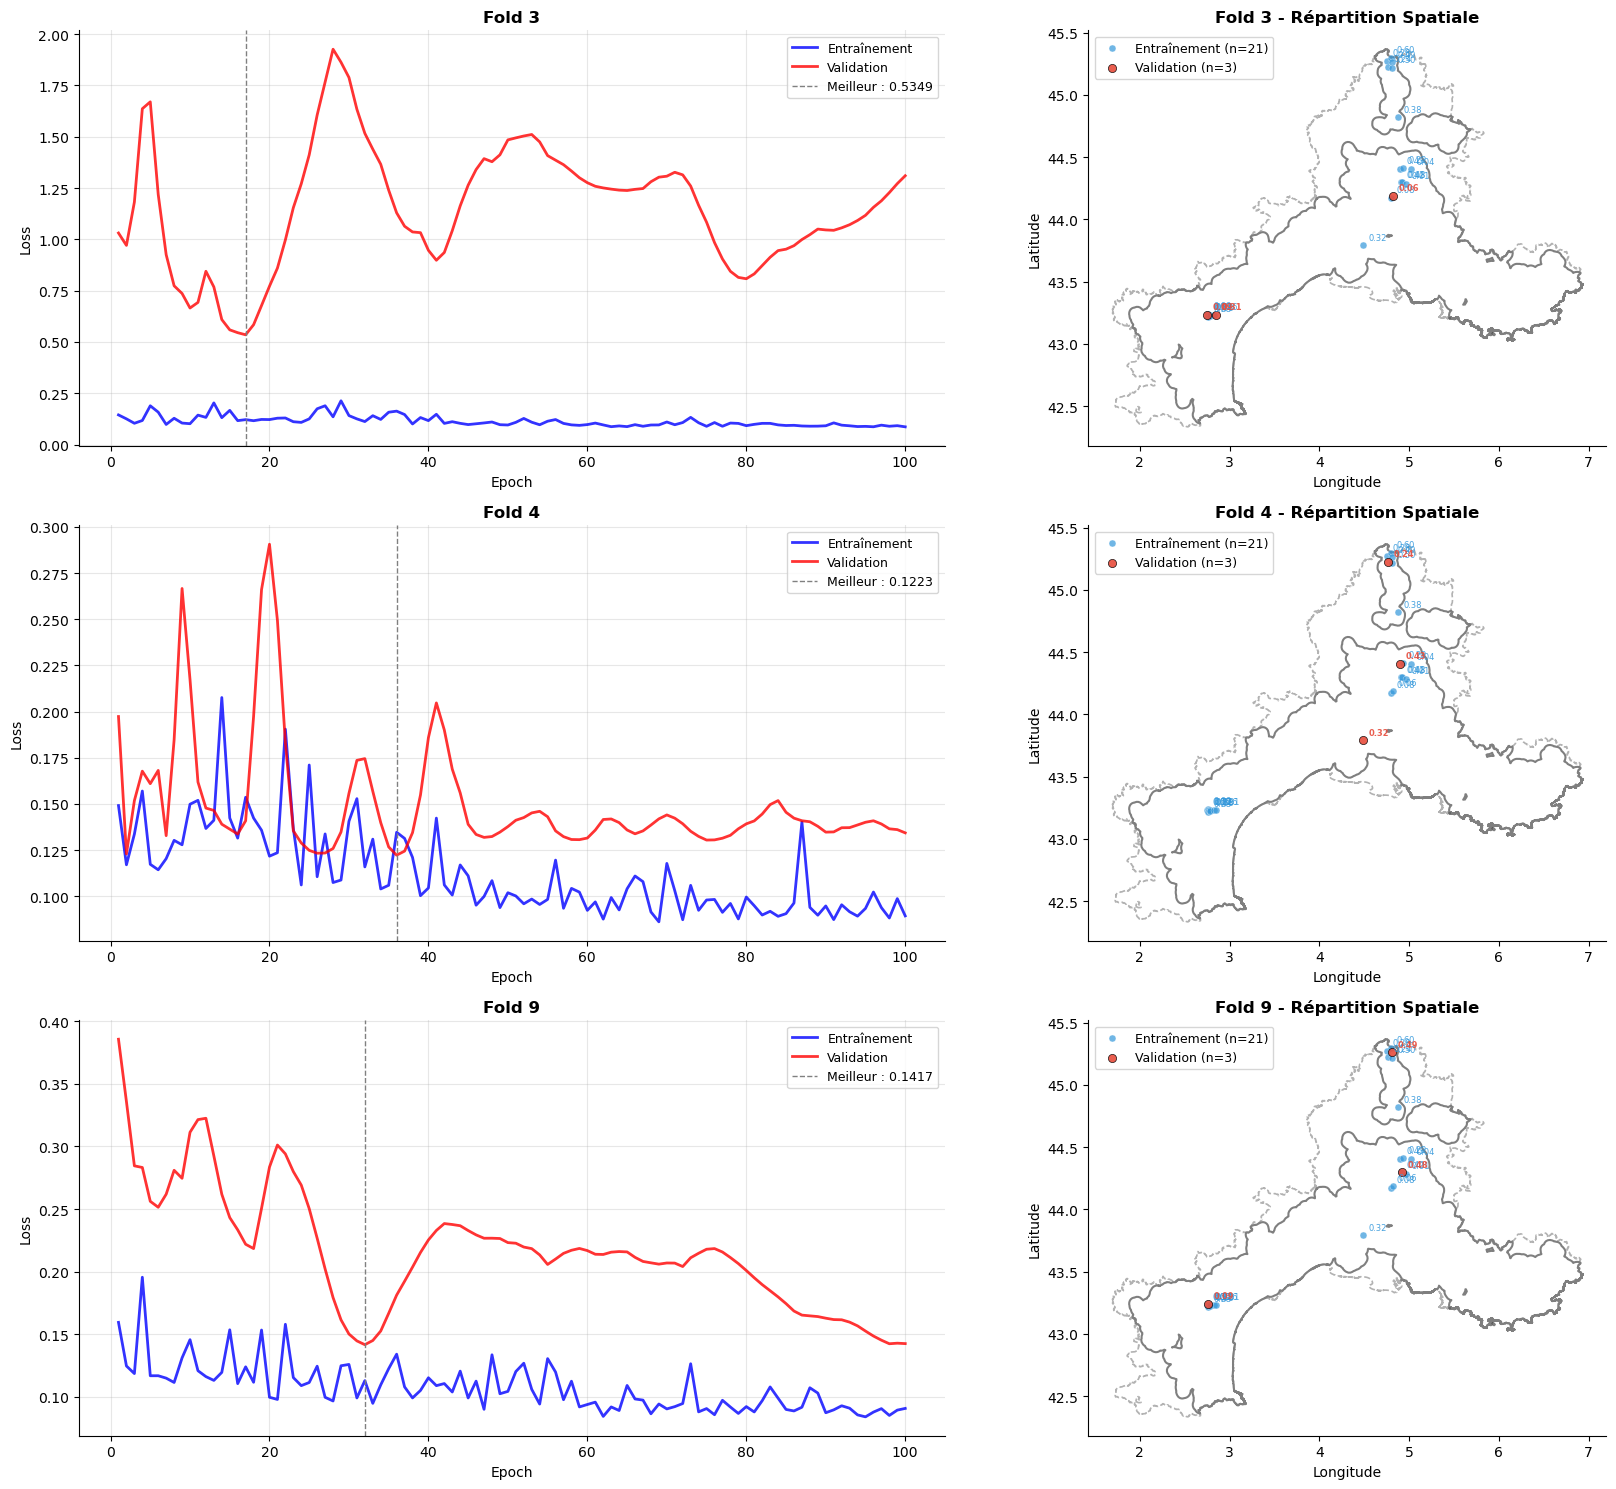

In [120]:
# n_valid_folds lignes, 2 colonnes (loss à gauche, carte à droite)
fig, axes = plt.subplots(n_valid_folds, 2, figsize=(18, 5 * n_valid_folds))

# si all_results ne contient qu'un seul fold (pour que axes reste une matrice 2D)
if n_valid_folds == 1:
    axes = np.expand_dims(axes, axis=0)

# recrée le générateur de split pour synchroniser les cartes avec les boucles de résultats
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
logo_viz = list(kf.split(X_obs))

# boucle sur les folds
for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)
    
    # récupération des indices géographiques correspondants au fold courant
    ind_train, ind_val = logo_viz[fold_idx]
    train_coords = coords_obs[ind_train]
    val_coords   = coords_obs[ind_val]

    # courbe de Loss
    ax_loss = axes[fold_idx, 0]
    ax_loss.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Entraînement', alpha=0.8)
    ax_loss.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Validation',   alpha=0.8)
    ax_loss.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                    color='gray', linestyle='--', linewidth=1,
                    label=f"Meilleur : {results_f['best_val_loss']:.4f}")
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'Fold {fold_data["fold"]}', fontweight='bold')
    ax_loss.legend(fontsize=9, loc='upper right')
    ax_loss.grid(True, alpha=0.3)
    ax_loss.spines['top'].set_visible(False)
    ax_loss.spines['right'].set_visible(False)

    # carte des observations
    ax_map = axes[fold_idx, 1]
    
    # dessin du contour de la zone d'étude
    study_zone_wgs.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
    study_zone_bg_wgs.plot(ax=ax_map, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

    # affichage des points d'entraînement (Bleu)
    ax_map.scatter(train_coords[:, 0], train_coords[:, 1],
                   c='#3498db', s=25, alpha=0.7, 
                   label=f'Entraînement (n={len(train_coords)})',
                   edgecolor='white', linewidth=0.3)
    
    # affichage des points de validation (Rouge)
    ax_map.scatter(val_coords[:, 0], val_coords[:, 1],
                   c='#e74c3c', s=35, alpha=0.9, 
                   label=f'Validation (n={len(val_coords)})',
                   edgecolor='black', linewidth=0.5)

    # annotation des valeurs iC-apex à côté des points
    igapex_train = ic_apex_obs[ind_train]
    igapex_val   = ic_apex_obs[ind_val]

    for (x, y), val in zip(train_coords, igapex_train):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#3498db', alpha=0.9)

    for (x, y), val in zip(val_coords, igapex_val):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#e74c3c', alpha=0.9, fontweight='bold')
    
    # personnalisation de l'axe de la carte
    ax_map.set_title(f'Fold {fold_data["fold"]} - Répartition Spatiale', fontsize=12, fontweight='bold')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.legend(fontsize=9, loc='upper left')
    ax_map.spines['top'].set_visible(False)
    ax_map.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print("📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD")
print("=" * 60)

all_val_preds = []
all_val_trues = []

for fold_data in all_results:
    model_f  = fold_data["results"]["model"]
    fold_idx = fold_data["fold"] - 1
    X_val_raw    = x_vals[fold_idx]
    y_val_f      = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f    = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f.eval()
    with torch.no_grad():
        logits    = model_f(X_val_tensor_f.to(device))               # (n_val, 2)
        val_preds = logits[:, 0].cpu().numpy() # score présence

    # Ratio présence par cellule
    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()

    all_val_preds.extend(val_preds)
    all_val_trues.extend(val_true)

    # Métrique locale
    tau, _ = kendalltau(val_true, val_preds)
    print(f"   Fold {fold_data['fold']:02d} ({len(val_true):02d} cellules) — Kendall τ : {tau:.4f}")

# --- MÉTRIQUES GLOBALES ---
print("\n" + "="*60)
print("📈 PERFORMANCE FINALE DU SYSTÈME SPATIAL (LOO)")
print("="*60)
y_pred_all    = np.array(all_val_preds)
y_true_all    = np.array(all_val_trues)
y_true_binary = (y_true_all >= 0.5).astype(int)   # majorité présences → 1
y_pred_class  = (y_pred_all >= 0.5).astype(int)

unique, counts = np.unique(y_true_binary, return_counts=True)
print(f"Labels dans y_true_binary : {dict(zip(unique, counts))}")

if len(np.unique(y_true_binary)) > 1:
    global_auc = roc_auc_score(y_true_binary, y_pred_all)
else:
    global_auc = float('nan')
    print("⚠️ AUC indéfinie : y_true ne contient qu'une seule classe")

global_acc     = accuracy_score(y_true_binary, y_pred_class)
global_tau, _  = kendalltau(y_true_all, y_pred_all)

print(f"   Nombre total de cellules validées  : {len(y_true_all)}")
print(f"   AUC-ROC Globale                    : {global_auc:.4f}  (discrimination binaire)")
print(f"   Accuracy Globale                   : {global_acc:.4f}  (seuil 0.5)")
print(f"   Kendall τ Global                   : {global_tau:.4f}  (corrélation des rangs)")

📊 ÉVALUATION GLOBALE (CUMULÉE) PAR FOLD


KeyError: 'val_preds'

In [ ]:
# ==============================================================================
# SCORE COMBINÉ OUT-OF-FOLD — même pipeline (MC-Dropout) que la grille finale
# ==============================================================================
oof_score_combined = []
oof_std_combined   = []
oof_ic_apex_true   = []
oof_fold_id        = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f = fold_data["results"]["model"]

    # Même fonction que pour la grille (predict_with_uncertainty, MC-Dropout)
    _, _, mean_nostress_v, std_presence_v, mean_stress_v, std_absence_v = predict_with_uncertainty(
        model=model_f, X_tensor=X_val_tensor_f, device=device, n_samples=100
    )

    p1_v, p2_v = np.asarray(mean_nostress_v), np.asarray(mean_stress_v)
    s1_v, s2_v = np.asarray(std_presence_v),  np.asarray(std_absence_v)

    score_v = p1_v * (1 - p2_v)
    std_v   = np.sqrt((1 - p2_v) ** 2 * s1_v ** 2 + p1_v ** 2 * s2_v ** 2)
    ic_apex_true_v = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()

    oof_score_combined.append(score_v)
    oof_std_combined.append(std_v)
    oof_ic_apex_true.append(ic_apex_true_v)
    oof_fold_id.extend([fold_data["fold"]] * len(score_v))

oof_score_combined = np.concatenate(oof_score_combined)
oof_std_combined    = np.concatenate(oof_std_combined)
oof_ic_apex_true    = np.concatenate(oof_ic_apex_true)
oof_fold_id         = np.array(oof_fold_id)

print(f"✅ {len(oof_score_combined)} paires (score_combined, iC-apex) OOF sur {len(all_results)} folds")

✅ 8 paires (score_combined, iC-apex) OOF sur 3 folds


In [ ]:
# 1. Récupération robuste du meilleur fold basé sur vos résultats effectifs
best_fold_id = best_fold["fold"]
# On cherche l'index correspondant dans votre liste de départ (au cas où des folds manquent)
best_fold_idx = best_fold_id - 1 

y_train_best = y_trains[best_fold_idx]
y_train_best_ratio = (y_train_best[:, 0] / (y_train_best[:, 0] + y_train_best[:, 1]))
X_train_best = x_trains[best_fold_idx]

print(f"📊 Corrélations covariables → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

# Nettoyage des noms de fichiers de vos rasters
var_names_clean = [
    f.replace('data/cov/rasters/', '')
     .replace('alt/', '').replace('cwb/', '').replace('ru/', '')
     .replace('.tif', '')
    for f in raster_files[:n_continuous]  # toutes les continues
]

# --- Partie 1 : Covariables continues ---
for i, name in enumerate(var_names_clean):
    x_col = X_train_best[:, i]
    y_col = y_train_best_ratio
    
    # ⚠️ SÉCURITÉ CRITIQUE : Le masque doit filtrer les NaNs de X ET s'assurer de l'alignement avec Y
    # On crée un masque combiné pour éliminer les lignes contenant un NaN dans l'une ou l'autre variable
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    # Si le masque élimine tout ou s'il n'y a pas assez de données pour une corrélation
    if mask.sum() < 2:
        print(f"   {name:40s} r = NaN (Données insuffisantes)")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {name:40s} r = {corr:.3f}")

# --- Partie 2 : Corrélations RU (one-hot) ---
print(f"📊 Corrélations RU (one-hot) → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    y_col = y_train_best_ratio
    
    # Même masque de sécurité combiné pour le One-Hot encoding
    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)
    
    if mask.sum() < 2:
        print(f"   RU classe {cls:<2} r = NaN")
        continue
        
    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    
    # Formattage propre des libellés (conforme à vos nouvelles classes du rouge au bleu)
    label = f"RU classe {cls}"
    if cls == 9:
        label += " (non-sol)"
    elif cls == 1:
        label += " (< 50mm)"
    elif cls == 2:
        label += " (50-100mm)"
    elif cls == 3:
        label += " (100-150mm)"
    elif cls == 4:
        label += " (150-200mm)"
    elif cls == 5:
        label += " (>= 200mm)"
        
    print(f"   {label:35s} r = {corr:.3f}")

# --- Partie 3 : Corrélations SAFRAN ---
print(f"📊 Corrélations SAFRAN → ratio présence iC-APEX (train fold {best_fold_id}) :")
print("=" * 65)

SAFRAN_start = n_continuous - len(COVARIABLES)  # = 20 - 16 = 4

for j, cov_name in enumerate(COVARIABLES):
    x_col = X_train_best[:, SAFRAN_start + j]
    y_col = y_train_best_ratio

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   {cov_name:40s} r = NaN (Données insuffisantes)")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]
    print(f"   {cov_name:40s} r = {corr:.3f}")

📊 Corrélations covariables → ratio présence iC-APEX (train fold 4) :
   alt\altitude_study_zone                  r = 0.027
   ru\ru_raster                             r = 0.010
   pente\slope                              r = 0.042
   exp\exposure                             r = -0.007
   CWB_1km_2025-08-10                       r = 0.258
   pluvio/PLUIE_CUM_1km_2025-08-10          r = -0.315
📊 Corrélations RU (one-hot) → ratio présence iC-APEX (train fold 4) :
   RU classe 1 (< 50mm)                r = -0.153
   RU classe 2 (50-100mm)              r = 0.063
   RU classe 3 (100-150mm)             r = nan
   RU classe 4 (150-200mm)             r = 0.046
   RU classe 5 (>= 200mm)              r = nan
   RU classe 9 (non-sol)               r = nan
📊 Corrélations SICLIMA → ratio présence iC-APEX (train fold 4) :
   dli_q                                    r = -0.315
   t_q                                      r = -0.255
   drainc_q                                 r = 0.311
   pe_q          

## 10. GENERATE IG-APEX MAP

In [ ]:
# Chargement de la study_zone globale (pour le fond de carte)
study_zone_bg = gpd.read_file("data/study_zone.gpkg")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")

# ==============================================================================
#  ÉTAPES COMPLÈTES : PRÉDICTION SUR TOUTE LA GRILLE VIA LE MEILLEUR FOLD
# ==============================================================================
# 1. Sélection automatique du meilleur Fold entraîné
best_fold_idx = np.argmax([r["val_auc"] for r in all_results])
best_fold = all_results[best_fold_idx]
model = best_fold["results"]["model"]
scaler_grid = best_fold["scaler"]
print(f"✅ Modèle et Scaler extraits avec succès depuis le Fold {best_fold['fold']}")

# 2. Masquage de sécurité pour les NaNs globaux
valid_grid_mask = ~torch.isnan(X_tensor).any(dim=1)
X_grid_clean = X_tensor[valid_grid_mask]

# 3. Normalisation rigoureuse (uniquement sur les variables continues)
X_grid_cont_scaled = scaler_grid.transform(X_grid_clean[:, :n_continuous].numpy())
X_grid_combined = np.concatenate([X_grid_cont_scaled, X_grid_clean[:, n_continuous:].numpy()], axis=1)
X_grid_final_tensor = torch.tensor(X_grid_combined, dtype=torch.float32)
print(f"📊 Nombre total de cellules dans la grille : {len(X_tensor):,}")
print(f"🎯 Cellules valides prêtes pour l'inférence : {len(X_grid_final_tensor):,}")

# 4. Inférence Spatiale avec Monte Carlo Dropout
print("🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...")
mean_pred, std_pred, mean_nostress, std_presence, mean_stress, std_absence = predict_with_uncertainty(
    model=model,
    X_tensor=X_grid_final_tensor,
    device=device,
    n_samples=100
)

# 5. Reconstruction des tenseurs complets (NaN pour les cellules invalides)
pred_presence_full = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
pred_absence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
std_presence_full  = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)
std_absence_full   = torch.full((len(X_tensor),), float('nan'), dtype=torch.float32)

pred_presence_full[valid_grid_mask] = mean_nostress
pred_absence_full[valid_grid_mask]  = mean_stress
std_presence_full[valid_grid_mask]  = std_presence
std_absence_full[valid_grid_mask]   = std_absence

print("🎉 Terminé !")
print(f"   pred_presence_full : {pred_presence_full.shape} — score DeepMaxEnt présences")
print(f"   pred_absence_full  : {pred_absence_full.shape}  — score DeepMaxEnt absences")
print(f"   std_presence_full  : {std_presence_full.shape}  — incertitude présences")
print(f"   std_absence_full   : {std_absence_full.shape}   — incertitude absences")

✅ Modèle et Scaler extraits avec succès depuis le Fold 4
📊 Nombre total de cellules dans la grille : 36,377
🎯 Cellules valides prêtes pour l'inférence : 33,473
🚀 Calcul des prédictions et de l'incertitude (MC-Dropout)...
🎉 Terminé !
   pred_presence_full : torch.Size([36377]) — score DeepMaxEnt présences
   pred_absence_full  : torch.Size([36377])  — score DeepMaxEnt absences
   std_presence_full  : torch.Size([36377])  — incertitude présences
   std_absence_full   : torch.Size([36377])   — incertitude absences


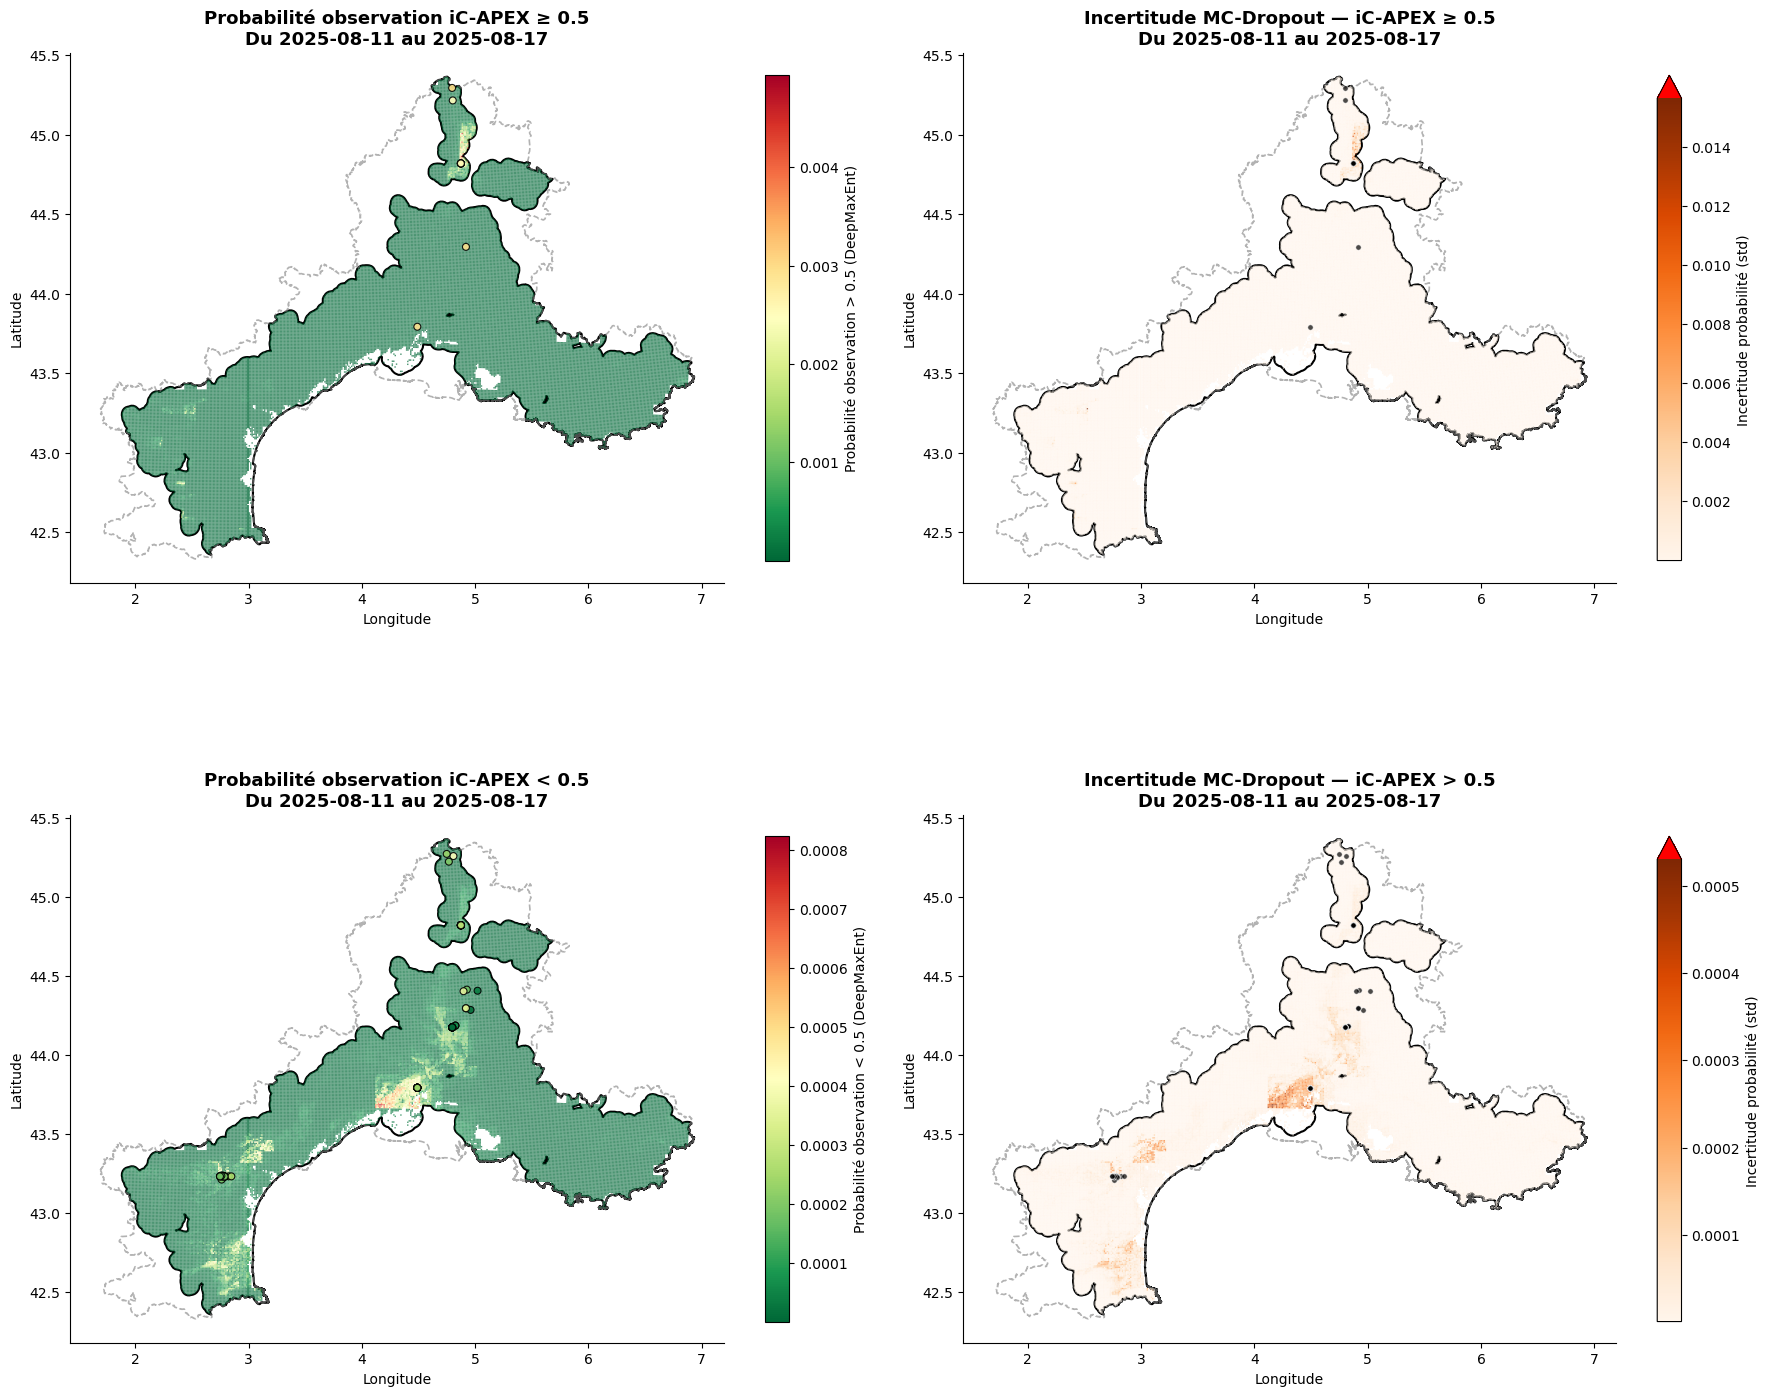

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Attribution des résultats à notre GeoDataFrame de la grille
grid_pred = grid_wgs.copy()
grid_pred['score_presence'] = pred_presence_full.numpy()
grid_pred['score_absence']  = pred_absence_full.numpy()
grid_pred['std_presence']   = std_presence_full.numpy()
grid_pred['std_absence']    = std_absence_full.numpy()

# Préparation de la variable terrain (on crée les objets géo une seule fois)
study_zone_wgs    = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
df_zone_wgs       = df_zone.to_crs("EPSG:4326").copy()

# Séparation des points terrain par classe
df_presences = df_zone_wgs[df_zone_wgs['ic_apex'] >= 0.5]
df_absences  = df_zone_wgs[df_zone_wgs['ic_apex'] <  0.5]

# Colormap incertitude
cmap_incertitude = plt.colormaps['Oranges'].copy()
cmap_incertitude.set_over('red')

# --- Génération des 4 cartes (2 lignes x 2 colonnes) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# ==============================================================
# LIGNE 1 : Classe iC-APEX <= 0.5
# ==============================================================

# --- Carte 1 : Score <0.5 ---
ax1 = axes[0, 0]
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['score_presence']).plot(
    ax=ax1, column='score_presence', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Probabilité observation > 0.5 (DeepMaxEnt)', 'shrink': 0.6}
    #vmin=0, vmax=1
)
df_presences.plot(
    ax=ax1, column='ic_apex', cmap='RdYlGn_r',
    markersize=25, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax1.set_title(f'Probabilité observation iC-APEX ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# --- Carte 2 : Incertitude <0.5 ---
ax2 = axes[0, 1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_presence']).plot(
    ax=ax2, column='std_presence', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_presences.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title(f'Incertitude MC-Dropout — iC-APEX ≥ 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# LIGNE 2 : Classe iC-APEX > 0.5
# ==============================================================

# --- Carte 3 : Score >0.5 ---
ax3 = axes[1, 0]
study_zone_wgs.plot(ax=ax3, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax3, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['score_absence']).plot(
    ax=ax3, column='score_absence', cmap='RdYlGn_r',
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Probabilité observation < 0.5 (DeepMaxEnt)', 'shrink': 0.6}
    #vmin=0, vmax=1
)
df_absences.plot(
    ax=ax3, column='ic_apex', cmap='RdYlGn_r',
    markersize=25, edgecolor='black', linewidth=0.8,
    alpha=0.9, legend=False, vmin=0, vmax=1
)
ax3.set_title(f'Probabilité observation iC-APEX < 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# --- Carte 4 : Incertitude >0.5 ---
ax4 = axes[1, 1]
study_zone_wgs.plot(ax=ax4, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax4, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_absence']).plot(
    ax=ax4, column='std_absence', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude probabilité (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_absences.plot(
    ax=ax4, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax4.set_title(f'Incertitude MC-Dropout — iC-APEX > 0.5\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# Finitions esthétiques
# ==============================================================
for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==============================================================
# 1. Calcul du score combiné p1*(1-p2) et de son incertitude propagée
# ==============================================================
p1 = pred_presence_full.numpy()
p2 = pred_absence_full.numpy()
s1 = std_presence_full.numpy()
s2 = std_absence_full.numpy()

score_combined = p1 * (1 - p2)
std_combined = np.sqrt((1 - p2) ** 2 * s1 ** 2 + p1 ** 2 * s2 ** 2)

# On complète grid_pred existant (créé en cellule 44) au lieu de l'écraser
grid_pred['score_combined'] = score_combined
grid_pred['std_combined']   = std_combined

# Préparation de la variable terrain
study_zone_wgs    = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
df_zone_wgs       = df_zone.to_crs("EPSG:4326").copy()

# Colormap incertitude
cmap_incertitude = plt.colormaps['Oranges'].copy()
cmap_incertitude.set_over('red')

In [40]:
import pickle
from pathlib import Path
import numpy as np

calibrators_path = Path(f"results/calibrators_{MODEL_TAG}.pkl")

if calibrators_path.exists():
    with open(calibrators_path, "rb") as f:
        calibrators = pickle.load(f)
    if date_debut_str in calibrators:
        calib_entry = calibrators[date_debut_str]
        calib = calib_entry["model"]
        print(f"Calibration {date_debut_str} : {calib_entry['n_points']} pts "
              f"(semaines poolées : {calib_entry['weeks_used']})")
        grid_pred['ic_apex_pred'] = np.nan  # initialise toute la colonne
        valid_mask = grid_pred['score_combined'].notna()
        grid_pred.loc[valid_mask, 'ic_apex_pred'] = calib.predict(
            grid_pred.loc[valid_mask, 'score_combined']
        )    
    else:
        print(f"⏩ Pas de calibrateur pour {date_debut_str} dans {calibrators_path} — "
              f"à régénérer après calibration.py.")
        grid_pred['ic_apex_pred'] = np.nan
else:
    print(f"⏩ {calibrators_path} n'existe pas encore — calibration ignorée pour cette exécution. "
          f"Normal lors du bootstrap initial : le notebook continue quand même jusqu'à l'export "
          f"OOF (cellule 56), lance calibration.py une fois que toutes les semaines sont passées, "
          f"puis relance ce notebook.")
    grid_pred['ic_apex_pred'] = np.nan

⏩ results\calibrators_classique.pkl n'existe pas encore — calibration ignorée pour cette exécution. Normal lors du bootstrap initial : le notebook continue quand même jusqu'à l'export OOF (cellule 56), lance calibration.py une fois que toutes les semaines sont passées, puis relance ce notebook.


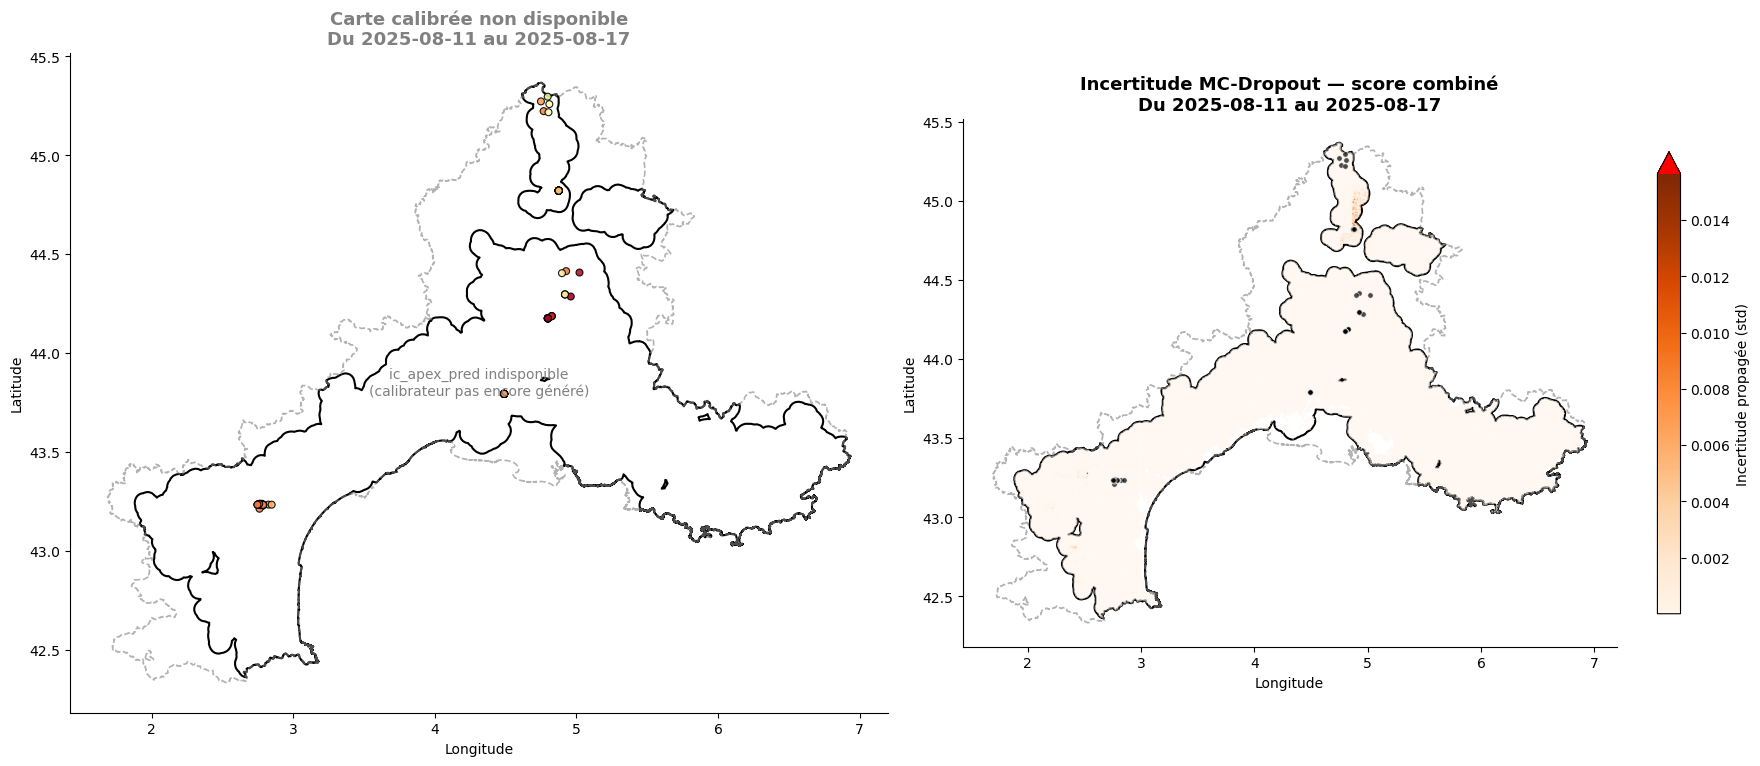

In [41]:
# --- Génération des 2 cartes (1 ligne x 2 colonnes) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ==============================================================
# Carte 1 : Score combiné p1*(1-p2)
# ==============================================================
ax1 = axes[0]
study_zone_wgs.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax1, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

if grid_pred['ic_apex_pred'].notna().any():
    grid_pred.dropna(subset=['ic_apex_pred']).plot(
        ax=ax1, column='ic_apex_pred', cmap='RdYlGn',
        vmin=0, vmax=1, legend=True, alpha=0.7,
        legend_kwds={'label': 'iC-apex prédit (calibré)', 'shrink': 0.6}
    )
    ax1.set_title(f'iC-apex prédit (calibré)\nDu {date_debut_str} au {date_fin_str}',
                  fontsize=13, fontweight='bold')
else:
    ax1.set_title(f'Carte calibrée non disponible\nDu {date_debut_str} au {date_fin_str}',
                  fontsize=13, fontweight='bold', color='gray')
    df_zone_wgs.plot(ax=ax1, column='ic_apex', cmap='RdYlGn', vmin=0, vmax=1,markersize=25, edgecolor='black', linewidth=0.8, alpha=0.9, legend=False)
    ax1.text(0.5, 0.5, 'ic_apex_pred indisponible\n(calibrateur pas encore généré)',
              ha='center', va='center', transform=ax1.transAxes, fontsize=10, color='gray')

# ==============================================================
# Carte 2 : Incertitude combinée
# ==============================================================
ax2 = axes[1]
study_zone_wgs.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=1.5)
study_zone_bg_wgs.plot(ax=ax2, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)
grid_pred.dropna(subset=['std_combined']).plot(
    ax=ax2, column='std_combined', cmap=cmap_incertitude,
    legend=True, alpha=0.7,
    legend_kwds={'label': 'Incertitude propagée (std)', 'shrink': 0.6, 'extend': 'max'}
)
df_zone_wgs.plot(
    ax=ax2, color='black',
    markersize=15, edgecolor='white', linewidth=0.5,
    alpha=0.7, legend=False
)
ax2.set_title(f'Incertitude MC-Dropout — score combiné\nDu {date_debut_str} au {date_fin_str}',
              fontsize=13, fontweight='bold')

# ==============================================================
# Finitions esthétiques
# ==============================================================
for ax in axes.flat:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- Sauvegarde en PNG ---
from pathlib import Path
Path("results/cartes").mkdir(parents=True, exist_ok=True)
plt.savefig(f"results/cartes/{MODEL_TAG}_{date_debut_str}.png", dpi=150, bbox_inches='tight')

plt.show()


In [44]:
# ==============================================================================
# RÉSUMÉ TABULÉ : Nb d'observations, nb de cellules observées et Kendall tau par fold
# ==============================================================================
import pandas as pd
from scipy.stats import kendalltau

nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()

summary_rows = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1

    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    tau, _ = kendalltau(val_true, val_preds)

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4)
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

valid_taus = df_summary["Kendall tau"].dropna()
print(f"Kendall tau moyen : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")

df_summary

Kendall tau moyen : 0.6055 ± 0.5323  (sur 3 folds)


,Nb observations,Nb cellules observées,Kendall tau
Fold,,,
3,95,24,0.0000
4,95,24,0.8165
9,95,24,1.0000


In [45]:
# ==============================================================================
# RÉSUMÉ TABULÉ : Nb d'observations, nb de cellules observées, Kendall tau et AUC-ROC par fold
# ==============================================================================
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import roc_auc_score

nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()

summary_rows = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1

    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan"),
            "AUC-ROC": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    tau, _ = kendalltau(val_true, val_preds)

    # Binarisation pour l'AUC-ROC (même seuil que dans le reste du notebook)
    val_true_binary = (val_true >= 0.5).astype(int)
    if len(np.unique(val_true_binary)) > 1:
        auc = roc_auc_score(val_true_binary, val_preds)
    else:
        auc = float("nan")  # AUC indéfinie si une seule classe présente dans le fold

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4),
        "AUC-ROC": round(auc, 4) if not np.isnan(auc) else float("nan")
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

valid_taus = df_summary["Kendall tau"].dropna()
valid_aucs = df_summary["AUC-ROC"].dropna()
print(f"Kendall tau moyen : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")
print(f"AUC-ROC moyen     : {valid_aucs.mean():.4f} ± {valid_aucs.std():.4f}  (sur {len(valid_aucs)} folds)")

df_summary

Kendall tau moyen : 0.6055 ± 0.5323  (sur 3 folds)
AUC-ROC moyen     : 0.8333 ± 0.2887  (sur 3 folds)


,Nb observations,Nb cellules observées,Kendall tau,AUC-ROC
Fold,,,,
3,95,24,0.0000,0.5
4,95,24,0.8165,1.0
9,95,24,1.0000,1.0


In [46]:
# ==============================================================================
# RÉSUMÉ TABULÉ : Nb d'observations, nb de cellules observées, Kendall tau, AUC-ROC
# et Balanced Accuracy par fold — on ne garde que les 3 meilleurs folds (Kendall tau)
# ==============================================================================
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import roc_auc_score

nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()
summary_rows = []
all_val_true = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan"),
            "AUC-ROC": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    all_val_true.append(val_true)
    tau, _ = kendalltau(val_true, val_preds)

    # Binarisation pour l'AUC-ROC et la Balanced Accuracy (même seuil que dans le reste du notebook)
    val_true_binary = (val_true >= 0.5).astype(int)

    if len(np.unique(val_true_binary)) > 1:
        auc = roc_auc_score(val_true_binary, val_preds)
    else:
        auc = float("nan")  # AUC indéfinie si une seule classe présente dans le fold

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4),
        "AUC-ROC": round(auc, 4) if not np.isnan(auc) else float("nan")
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

# --- Sélection des 3 meilleurs folds selon le Kendall tau (moins si pas assez disponibles) ---
# na_position="last" : un fold à Kendall tau NaN n'est gardé que s'il ne reste pas
# assez de folds valides pour compléter le top 3.
N_BEST_FOLDS = 3
df_summary = df_summary.sort_values("Kendall tau", ascending=False, na_position="last").head(N_BEST_FOLDS)

valid_taus     = df_summary["Kendall tau"].dropna()
valid_aucs     = df_summary["AUC-ROC"].dropna()

print(f"Kendall tau moyen        : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")
print(f"AUC-ROC moyen            : {valid_aucs.mean():.4f} ± {valid_aucs.std():.4f}  (sur {len(valid_aucs)} folds)")

df_summary

Kendall tau moyen        : 0.6055 ± 0.5323  (sur 3 folds)
AUC-ROC moyen            : 0.8333 ± 0.2887  (sur 3 folds)


,Nb observations,Nb cellules observées,Kendall tau,AUC-ROC
Fold,,,,
9,95,24,1.0000,1.0
4,95,24,0.8165,1.0
3,95,24,0.0000,0.5


In [47]:
import pickle
import numpy as np
from pathlib import Path

val_true_concat = np.concatenate(all_val_true) if all_val_true else np.array([])
ic_apex_moy = float(val_true_concat.mean()) if len(val_true_concat) else float("nan")
std_ic_apex = float(val_true_concat.std())  if len(val_true_concat) else float("nan")

export_data = {
    "date_debut_str": date_debut_str,
    "df_summary": df_summary,
    "ic_apex_moy": ic_apex_moy,
    "std_ic_apex": std_ic_apex,
    "oof_score_combined": oof_score_combined,
    "oof_std_combined": oof_std_combined,
    "oof_ic_apex_true": oof_ic_apex_true,
}

Path("results").mkdir(exist_ok=True)
with open(f"results/{MODEL_TAG}_{date_debut_str}.pkl", "wb") as f:
    pickle.dump(export_data, f)

print(f"✅ Résultats exportés : results/{MODEL_TAG}_{date_debut_str}.pkl")

✅ Résultats exportés : results/classique_2025-08-11.pkl
